

1.   Initalize the Weights
2.   Choose Optimization Algorithm
3.   Repeat these steps:
  *   Forward propagate and Input
  *   Compute the cost function
  *   Compute gradients of cost function with respect to the parameters (weights)
  *   Update each parameter using gradient according to the optimization algorithm







Case 1: Zero initalization



1.   ReLU
2.   TanH
3.   Sigmoid



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
df = pd.read_csv('/content/ushape1.csv')

In [ ]:
df

,X,Y,Class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0
...,...,...,...
95,1.7000,0.5880,1.0
96,0.2190,-0.6530,1.0
97,0.9530,-0.4200,1.0
98,-1.3200,0.4230,0.0


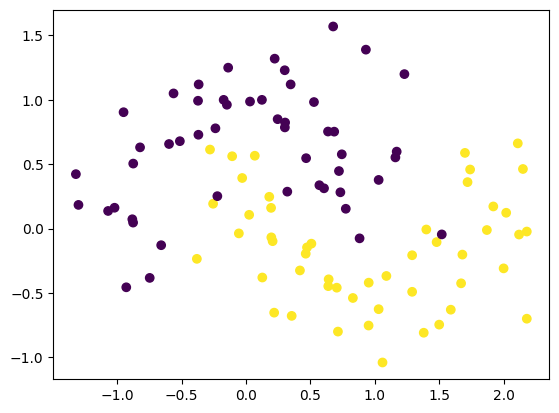

In [ ]:
plt.scatter(df["X"], df["Y"], c=df["Class"])

In [ ]:
x, y = df.iloc[:, 0:2].values, df.iloc[:, 2].values

In [ ]:
x

array([[ 0.0316 ,  0.987  ],
       [ 2.12   , -0.0462 ],
       [ 0.882  , -0.0758 ],
       [-0.0551 , -0.0373 ],
       [ 0.83   , -0.539  ],
       [ 2.11   ,  0.662  ],
       [ 0.57   ,  0.337  ],
       [ 0.952  , -0.753  ],
       [-0.0292 ,  0.393  ],
       [ 1.72   ,  0.361  ],
       [-0.279  ,  0.614  ],
       [ 2.     , -0.309  ],
       [ 1.5    , -0.746  ],
       [ 1.23   ,  1.2    ],
       [ 0.467  ,  0.547  ],
       [-0.367  ,  1.12   ],
       [ 0.301  ,  1.23   ],
       [ 0.304  ,  0.824  ],
       [-0.237  ,  0.779  ],
       [ 1.16   ,  0.553  ],
       [-0.597  ,  0.657  ],
       [ 0.464  , -0.195  ],
       [ 0.685  ,  0.753  ],
       [ 0.705  , -0.459  ],
       [-0.658  , -0.129  ],
       [-0.747  , -0.383  ],
       [ 0.606  ,  0.313  ],
       [ 2.18   , -0.0229 ],
       [ 1.92   ,  0.172  ],
       [ 1.48   , -0.105  ],
       [ 0.474  , -0.146  ],
       [ 1.06   , -1.04   ],
       [ 1.87   , -0.0111 ],
       [ 0.419  , -0.325  ],
       [ 0.068

In [ ]:
y

array([0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1.,
       0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 0.,
       1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 0., 0.])

In [ ]:
model = Sequential()
model.add(Dense(2, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.get_weights()

[array([[ 0.5007545 , -0.42423797],
        [-1.0866354 ,  0.363788  ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.3519057],
        [ 1.0360461]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
initial_weights = model.get_weights()

In [ ]:
initial_weights

[array([[ 0.5007545 , -0.42423797],
        [-1.0866354 ,  0.363788  ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.3519057],
        [ 1.0360461]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
initial_weights[0]

array([[ 0.5007545 , -0.42423797],
       [-1.0866354 ,  0.363788  ]], dtype=float32)

In [ ]:
initial_weights[1]

array([0., 0.], dtype=float32)

In [ ]:
initial_weights[0] = np.zeros(initial_weights[0].shape)
initial_weights[1] = np.zeros(initial_weights[1].shape)
initial_weights[2] = np.zeros(initial_weights[2].shape)
initial_weights[3] = np.zeros(initial_weights[3].shape)

In [ ]:
model.set_weights(initial_weights)

In [ ]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history = model.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.4078 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4844 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4805 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5078 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4805 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5352 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss

In [ ]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.00103781], dtype=float32)]

  49/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step  

<ipython-input-23-5116975b4946>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

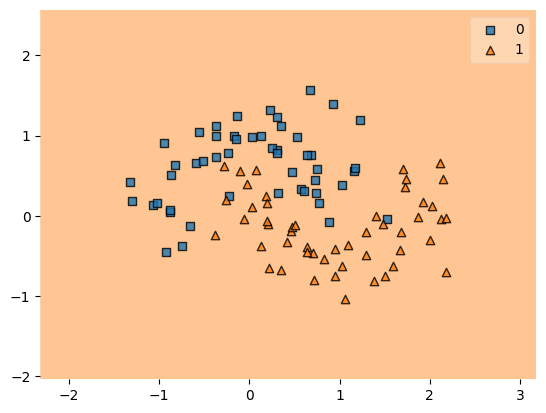

In [ ]:
plot_decision_regions(x, y.astype(np.integer), clf=model)

In [ ]:
model1 = Sequential()
model1.add(Dense(2, input_dim=2, activation='tanh'))
model1.add(Dense(1, activation='sigmoid'))

In [ ]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
initial_weights1 = model1.get_weights()

In [ ]:
initial_weights1[0] = np.zeros(initial_weights1[0].shape)
initial_weights1[1] = np.zeros(initial_weights1[1].shape)
initial_weights1[2] = np.zeros(initial_weights1[2].shape)
initial_weights1[3] = np.zeros(initial_weights1[3].shape)

In [ ]:
model1.set_weights(initial_weights1)

In [ ]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history1 = model1.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.4719 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5156 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5273 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4609 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5156 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4922 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4688 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5312 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss

In [ ]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.00103781], dtype=float32)]

<ipython-input-32-97ec1e121ad1>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model1)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

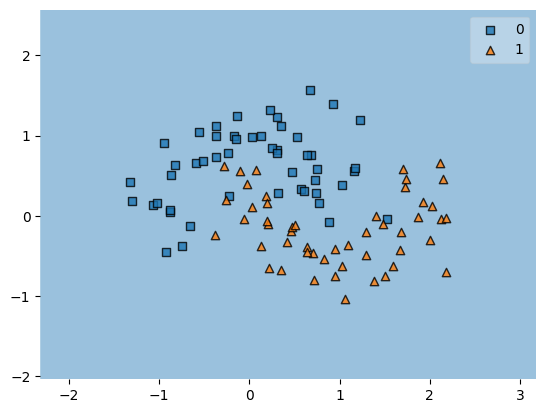

In [ ]:
plot_decision_regions(x, y.astype(np.integer), clf=model1)

In [ ]:
model2 = Sequential()
model2.add(Dense(2, input_dim=2, activation='sigmoid'))
model2.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
initial_weights2 = model2.get_weights()

In [ ]:
initial_weights2[0] = np.zeros(initial_weights2[0].shape)
initial_weights2[1] = np.zeros(initial_weights2[1].shape)
initial_weights2[2] = np.zeros(initial_weights2[2].shape)
initial_weights2[3] = np.zeros(initial_weights2[3].shape)

In [ ]:
model2.set_weights(initial_weights2)

In [ ]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history2 = model2.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.5078 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4477 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4844 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5469 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5508 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4688 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4883 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss

In [ ]:
model2.get_weights()

[array([[ 0.47950524,  0.47950524],
        [-0.50394505, -0.50394505]], dtype=float32),
 array([-0.08515605, -0.08515605], dtype=float32),
 array([[0.0994438],
        [0.0994438]], dtype=float32),
 array([-0.02373743], dtype=float32)]

  48/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step  

<ipython-input-42-4da1a2961f74>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model2)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

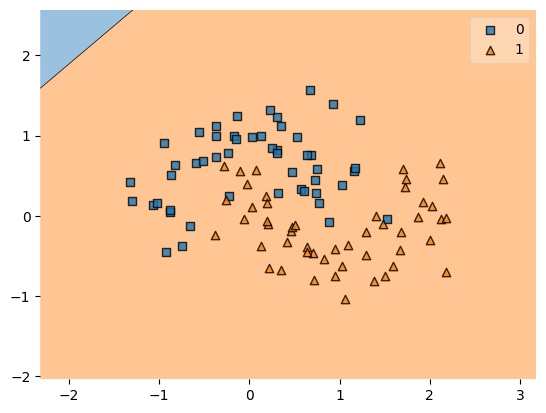

In [ ]:
plot_decision_regions(x, y.astype(np.integer), clf=model2)

Initialization as a constant:



1.   ReLU
2.   TanH
3.   Sigmoid



In [ ]:
model3 = Sequential()
model3.add(Dense(2, input_dim=2, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
initial_weights3 = model3.get_weights()

In [ ]:
initial_weights3[0]=np.ones(model3.get_weights()[0].shape)*0.5
initial_weights3[1]=np.ones(model3.get_weights()[1].shape)*0.5
initial_weights3[2]=np.ones(model3.get_weights()[2].shape)*0.5
initial_weights3[3]=np.ones(model3.get_weights()[3].shape)*0.5

In [ ]:
model3.set_weights(initial_weights3)

In [ ]:
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history3 = model3.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.4844 - loss: 0.9499 - val_accuracy: 0.5000 - val_loss: 0.8203
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4922 - loss: 0.9484 - val_accuracy: 0.5000 - val_loss: 0.8174
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5234 - loss: 0.8949 - val_accuracy: 0.5000 - val_loss: 0.8146
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5000 - loss: 0.9130 - val_accuracy: 0.5000 - val_loss: 0.8117
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5391 - loss: 0.8763 - val_accuracy: 0.5000 - val_loss: 0.8089
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4844 - loss: 0.9326 - val_accuracy: 0.5000 - val_loss: 0.8062
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4883 - loss: 0.9229 - val_accuracy: 0.5000 - val_loss: 0.8035
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5508 - loss: 0.8440 - val_accuracy: 0.5000 - val_loss

In [ ]:
model3.get_weights()

[array([[0.52746147, 0.52746147],
        [0.25270176, 0.25270176]], dtype=float32),
 array([0.30294016, 0.30294016], dtype=float32),
 array([[0.29264072],
        [0.29264072]], dtype=float32),
 array([0.2536468], dtype=float32)]

<ipython-input-56-655aa3d4ba41>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model3)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

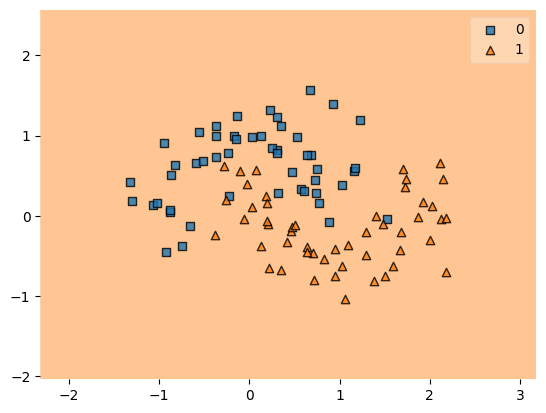

In [ ]:
plot_decision_regions(x, y.astype(np.integer), clf=model3)

In [ ]:
model4 = Sequential()
model4.add(Dense(2, input_dim=2, activation='tanh'))
model4.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
initial_weights4 = model4.get_weights()

In [ ]:
initial_weights4[0]=np.ones(model4.get_weights()[0].shape)*0.5
initial_weights4[1]=np.ones(model4.get_weights()[1].shape)*0
initial_weights4[2]=np.ones(model4.get_weights()[2].shape)*0.5
initial_weights4[3]=np.ones(model4.get_weights()[3].shape)*0.5

In [ ]:
model4.set_weights(initial_weights4)

In [ ]:
model4.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history4 = model4.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4984 - loss: 0.8058 - val_accuracy: 0.6000 - val_loss: 0.7043
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5219 - loss: 0.7913 - val_accuracy: 0.6000 - val_loss: 0.7026
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5219 - loss: 0.7815 - val_accuracy: 0.6000 - val_loss: 0.7009
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4945 - loss: 0.7909 - val_accuracy: 0.6000 - val_loss: 0.6992
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5063 - loss: 0.7905 - val_accuracy: 0.6000 - val_loss: 0.6975
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5063 - loss: 0.7943 - val_accuracy: 0.6000 - val_loss: 0.6959
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5180 - loss: 0.7598 - val_accuracy: 0.6000 - val_loss: 0.6942
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5023 - loss: 0.7926 - val_accuracy: 0.6000 - val_loss

In [ ]:
model4.get_weights()

[array([[0.68872964, 0.68872964],
        [0.2287205 , 0.2287205 ]], dtype=float32),
 array([-0.22311397, -0.22311397], dtype=float32),
 array([[0.38453424],
        [0.38453424]], dtype=float32),
 array([0.26918885], dtype=float32)]

<ipython-input-65-acad445bdf43>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model4)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

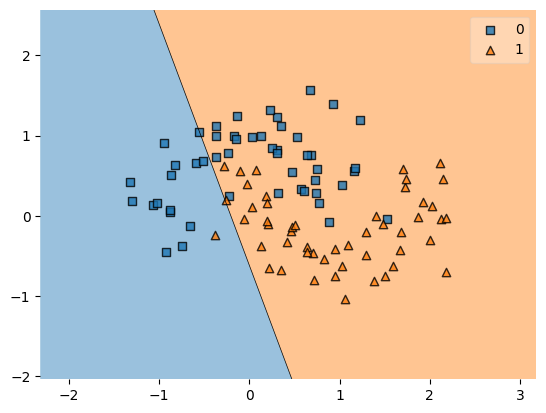

In [ ]:
plot_decision_regions(x, y.astype(np.integer), clf=model4)

In [ ]:
model5 = Sequential()
model5.add(Dense(2, input_dim=2, activation='sigmoid'))
model5.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
initial_weights5 = model5.get_weights()

In [ ]:
initial_weights5[0]=np.ones(model5.get_weights()[0].shape)*0.5
initial_weights5[1]=np.ones(model5.get_weights()[1].shape)*0.5
initial_weights5[2]=np.ones(model5.get_weights()[2].shape)*0.5
initial_weights5[3]=np.ones(model5.get_weights()[3].shape)*0.5

In [ ]:
model5.set_weights(initial_weights5)

In [ ]:
model5.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history5 = model5.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.4961 - loss: 0.8704 - val_accuracy: 0.5000 - val_loss: 0.8362
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4766 - loss: 0.8906 - val_accuracy: 0.5000 - val_loss: 0.8341
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 0.8597 - val_accuracy: 0.5000 - val_loss: 0.8322
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5312 - loss: 0.8237 - val_accuracy: 0.5000 - val_loss: 0.8302
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5078 - loss: 0.8414 - val_accuracy: 0.5000 - val_loss: 0.8282
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4688 - loss: 0.8871 - val_accuracy: 0.5000 - val_loss: 0.8262
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5000 - loss: 0.8510 - val_accuracy: 0.5000 - val_loss: 0.8242
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.8485 - val_accuracy: 0.5000 - val_loss

In [ ]:
model5.get_weights()

[array([[0.711528  , 0.711528  ],
        [0.24655071, 0.24655071]], dtype=float32),
 array([0.2764905, 0.2764905], dtype=float32),
 array([[0.26700622],
        [0.26700622]], dtype=float32),
 array([0.25362873], dtype=float32)]

  47/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step  

<ipython-input-75-e465dea5bf9b>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model5)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

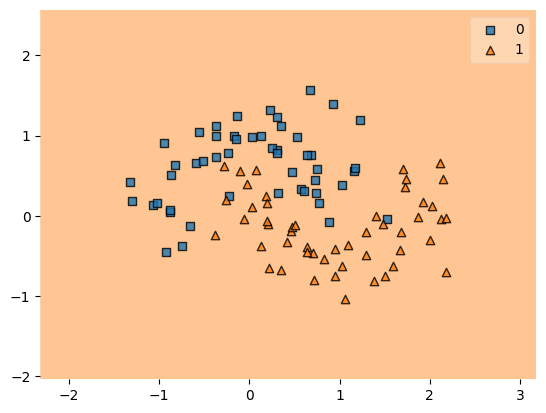

In [ ]:
plot_decision_regions(x, y.astype(np.integer), clf=model5)

Case 3: small random value initialization



1.   ReLU
2.   TanH
3.   Sigmoid



In [ ]:
model6 = Sequential()
model6.add(Dense(2, input_dim=2, activation='relu'))
model6.add(Dense(2, activation='sigmoid'))
model6.add(Dense(2, activation='sigmoid'))
model6.add(Dense(2, activation='sigmoid'))
model6.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model6.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                     │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
initial_weights6 = model6.get_weights()

In [ ]:
initial_weights6[0]=np.random.randn(model6.get_weights()[0].shape[0],model6.get_weights()[0].shape[1])*0.01
initial_weights6[1]=np.zeros(model6.get_weights()[1].shape)
initial_weights6[2]=np.random.randn(model6.get_weights()[2].shape[0],model6.get_weights()[2].shape[1])*0.01
initial_weights6[3]=np.zeros(model6.get_weights()[3].shape)
initial_weights6[4]=np.random.randn(model6.get_weights()[4].shape[0],model6.get_weights()[4].shape[1])*0.01
initial_weights6[5]=np.zeros(model6.get_weights()[5].shape)
initial_weights6[6]=np.random.randn(model6.get_weights()[6].shape[0],model6.get_weights()[6].shape[1])*0.01
initial_weights6[7]=np.zeros(model6.get_weights()[7].shape[0])
initial_weights6[8]=np.random.randn(model6.get_weights()[8].shape[0],model6.get_weights()[8].shape[1])*0.01
initial_weights6[9]=np.zeros(model6.get_weights()[9].shape[0])

In [ ]:
model6.set_weights(initial_weights6)

In [ ]:
model6.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history6 = model6.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.4836 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5078 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4883 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4883 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5195 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4805 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5195 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss

In [ ]:
model6.get_weights()

[array([[-0.00147414,  0.01144479],
        [ 0.01706539,  0.00343735]], dtype=float32),
 array([-7.329041e-05, -5.628936e-06], dtype=float32),
 array([[-0.01855866,  0.0175826 ],
        [ 0.00065075, -0.01275274]], dtype=float32),
 array([ 5.7809275e-06, -3.4075532e-05], dtype=float32),
 array([[-0.00685286, -0.01351518],
        [ 0.00655795, -0.00479618]], dtype=float32),
 array([-0.00449115, -0.00011394], dtype=float32),
 array([[-0.00599925, -0.00951687],
        [-0.02321783, -0.00281638]], dtype=float32),
 array([-0.01557921,  0.00160529], dtype=float32),
 array([[-0.00401896],
        [-0.00959893]], dtype=float32),
 array([-0.00735263], dtype=float32)]

<ipython-input-85-3b148ca8bc70>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model6)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

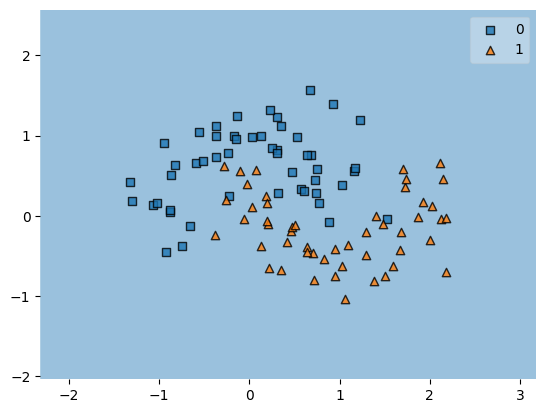

In [ ]:
plot_decision_regions(x, y.astype(np.integer), clf=model6)

In [ ]:
model7 = Sequential()
model7.add(Dense(2, input_dim=2, activation='tanh'))
model7.add(Dense(2, activation='sigmoid'))
model7.add(Dense(2, activation='sigmoid'))
model7.add(Dense(2, activation='sigmoid'))
model7.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
initial_weights7 = model7.get_weights()

In [ ]:
initial_weights7[0]=np.random.randn(model7.get_weights()[0].shape[0],model7.get_weights()[0].shape[1])*0.01
initial_weights7[1]=np.zeros(model7.get_weights()[1].shape)
initial_weights7[2]=np.random.randn(model7.get_weights()[2].shape[0],model7.get_weights()[2].shape[1])*0.01
initial_weights7[3]=np.zeros(model7.get_weights()[3].shape)
initial_weights7[4]=np.random.randn(model7.get_weights()[4].shape[0],model7.get_weights()[4].shape[1])*0.01
initial_weights7[5]=np.zeros(model7.get_weights()[5].shape)
initial_weights7[6]=np.random.randn(model7.get_weights()[6].shape[0],model7.get_weights()[6].shape[1])*0.01
initial_weights7[7]=np.zeros(model7.get_weights()[7].shape[0])
initial_weights7[8]=np.random.randn(model7.get_weights()[8].shape[0],model7.get_weights()[8].shape[1])*0.01
initial_weights7[9]=np.zeros(model7.get_weights()[9].shape[0])

In [ ]:
model7.set_weights(initial_weights7)

In [ ]:
model7.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history7 = model7.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.4117 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4844 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4414 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5312 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4727 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5273 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.5156 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5078 - loss: 0.6931 - val_accuracy: 0.5000 - val_lo

In [ ]:
model7.get_weights()

[array([[0.02796846, 0.00707708],
        [0.00540294, 0.00528569]], dtype=float32),
 array([-1.3779573e-08, -1.7244095e-07], dtype=float32),
 array([[ 0.01462823, -0.01138496],
        [-0.01673874,  0.01999005]], dtype=float32),
 array([-1.8517781e-05, -2.4249473e-05], dtype=float32),
 array([[ 0.01401457, -0.00166945],
        [ 0.00361724,  0.00624265]], dtype=float32),
 array([ 0.0009184 , -0.00290113], dtype=float32),
 array([[-0.01337347, -0.01283587],
        [-0.00376484, -0.0084221 ]], dtype=float32),
 array([-0.00525043, -0.00738838], dtype=float32),
 array([[-0.00888842],
        [-0.00435952]], dtype=float32),
 array([-0.00734373], dtype=float32)]

  45/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step   

<ipython-input-94-3430e56f272b>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model7)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


<Axes: >

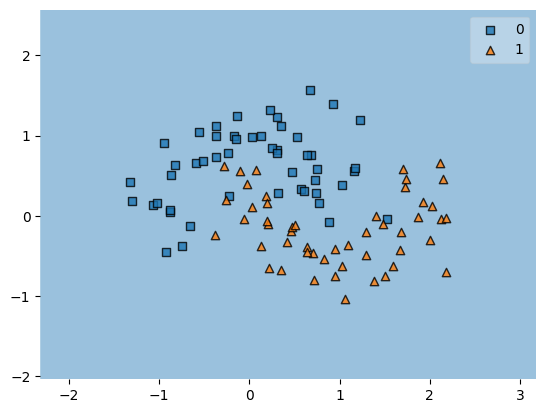

In [ ]:
plot_decision_regions(x, y.astype(np.integer), clf=model7)

In [ ]:
model8 = Sequential()
model8.add(Dense(2, input_dim=2, activation='sigmoid'))
model8.add(Dense(2, activation='sigmoid'))
model8.add(Dense(2, activation='sigmoid'))
model8.add(Dense(2, activation='sigmoid'))
model8.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model8.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
initial_weights8 = model8.get_weights()

In [ ]:
initial_weights8[0]=np.random.randn(model8.get_weights()[0].shape[0],model8.get_weights()[0].shape[1])*0.01
initial_weights8[1]=np.zeros(model8.get_weights()[1].shape)
initial_weights8[2]=np.random.randn(model8.get_weights()[2].shape[0],model8.get_weights()[2].shape[1])*0.01
initial_weights8[3]=np.zeros(model8.get_weights()[3].shape)
initial_weights8[4]=np.random.randn(model8.get_weights()[4].shape[0],model8.get_weights()[4].shape[1])*0.01
initial_weights8[5]=np.zeros(model8.get_weights()[5].shape)
initial_weights8[6]=np.random.randn(model8.get_weights()[6].shape[0],model8.get_weights()[6].shape[1])*0.01
initial_weights8[7]=np.zeros(model8.get_weights()[7].shape[0])
initial_weights8[8]=np.random.randn(model8.get_weights()[8].shape[0],model8.get_weights()[8].shape[1])*0.01
initial_weights8[9]=np.zeros(model8.get_weights()[9].shape[0])

In [ ]:
model8.set_weights(initial_weights8)

In [ ]:
model8.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history8 = model8.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 366ms/step - accuracy: 0.4922 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4570 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4883 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5195 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4961 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4883 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4609 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss

In [ ]:
model8.get_weights()

[array([[ 0.00667534,  0.00059395],
        [-0.01037164,  0.00743969]], dtype=float32),
 array([-1.5611546e-07,  4.5285116e-08], dtype=float32),
 array([[ 0.00927268,  0.00347154],
        [-0.01395962,  0.00914097]], dtype=float32),
 array([-4.6898858e-05, -5.1668765e-05], dtype=float32),
 array([[-0.00555954,  0.0061489 ],
        [-0.00839872, -0.01081829]], dtype=float32),
 array([ 0.0026025 , -0.00063686], dtype=float32),
 array([[-0.01927244, -0.02090436],
        [ 0.00739291, -0.03106862]], dtype=float32),
 array([-0.00521212, -0.02108619], dtype=float32),
 array([[0.00869454],
        [0.00097403]], dtype=float32),
 array([-0.00239643], dtype=float32)]

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 12:18 77ms/step

<ipython-input-103-5d465e54dee8>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model8)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

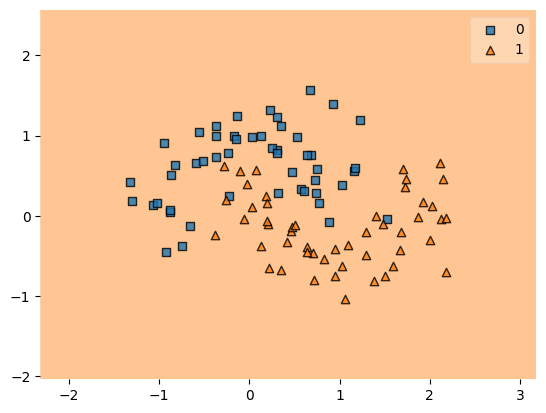

In [ ]:
plot_decision_regions(x, y.astype(np.integer), clf=model8)